In [1]:
import os
import yaml 
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from model_utils import estModel

In [ ]:
model_PATH = "best.pth"
yaml_PATH = "data_test.yaml" # Use same xml as used for training
image_PATH = "dataset/valid/images/Cats_Test35.png"
fov = 0.1 # FOV value of this image
image_size  = 640 # Ensure this value is same as used in training
threshold = 0.7 # show objects with > 70% confidence scores

In [ ]:
def read_YAML(path):
    assert os.path.exists(path), f"File doesn't exist: {path}"
    # Read data.yaml
    with open(path, 'r') as file:
        contents = yaml.safe_load(file)

    return contents['nc'], contents['names']

def scale_IMG(path, size=None):
    image = cv2.imread(path, cv2.IMREAD_COLOR_BGR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR to RGB

    if (size):
        h, w, _ = image.shape
        aspect_ratio = h / w
        n_w = int(size)
        n_h = int(aspect_ratio * n_w)
                    
        image = cv2.resize(image, (n_w, n_h), interpolation=cv2.INTER_AREA)

    return torch.tensor(np.transpose(image, (2, 0, 1)), dtype=torch.float32) / 255.0 

In [ ]:
# Read YAML file to get 
num_classes, class_names  = read_YAML(yaml_PATH)

# Read an image
image = scale_IMG(image_PATH, image_size)
# Create input dictionary with image and fov
inputs = {'image': image, 'fov': torch.tensor(fov, dtype=torch.float32)}

# create class to int and vice versa dictionary [to be used for visualization]
cls_int = {c: i+1 for i, c in enumerate(class_names)}
cls_int['background'] = 0
int_cls = { values:keys for keys, values in cls_int.items()}

# Init model
device = "cpu" #torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = estModel(num_classes=num_classes + 1).to(device)
model.load_state_dict(torch.load(model_PATH))

# Inference on single image
model.eval()
with torch.no_grad():
    output = model([{k: v.to(device) for k, v in inputs.items()}])[0]

# Filter predictions by score threshold
boxes = output['boxes'].cpu()
labels = output['labels'].cpu()
scores = output['scores'].cpu()
distances = output['distances'].cpu()

selected_indices = scores > threshold
boxes = boxes[selected_indices]
labels = labels[selected_indices]
scores = scores[selected_indices]
distances = distances[selected_indices]
print(boxes, labels, scores, distances)


torch.Size([3, 480, 640])


tensor([[104.7769,  85.1907, 396.8430, 302.6028]]) tensor([1]) tensor([0.9933]) tensor([0.4948])


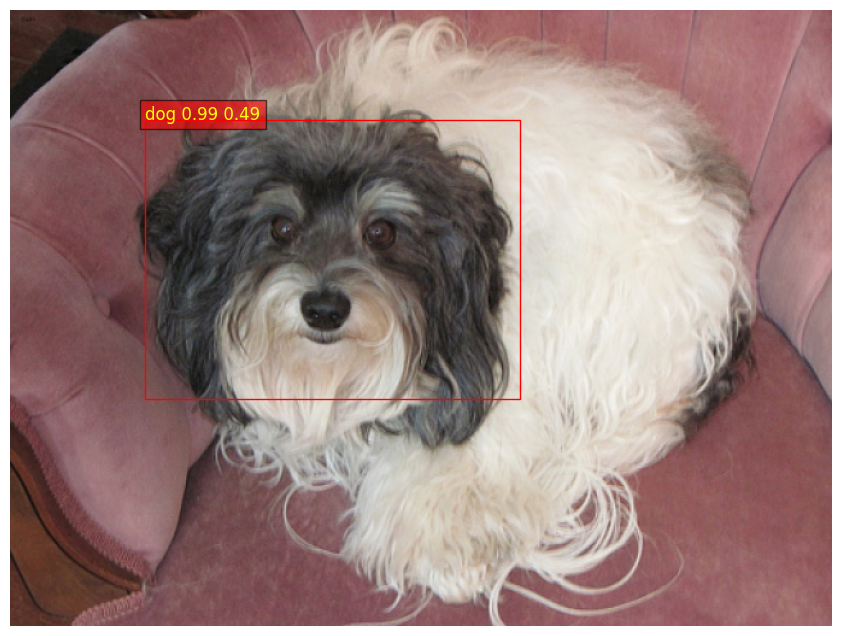

In [9]:
# Visualize on a single image
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(np.transpose(image, (1, 2, 0)))

for box, label, score, distance in zip(boxes, labels, scores, distances):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=1, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    class_name = int_cls[label.item()]
    ax.text(x1, y1, f"{class_name} {score:.2f} {distance:.2f}", color='yellow',
            fontsize=12, bbox=dict(facecolor='red', alpha=0.6))

plt.axis('off')
plt.show()